# Feature engineering

## Load the dataset

Load the dataset processed in the previous notebook.

In [2]:
import pandas as pd

exploratory_df = pd.read_csv("dataset/processed/exploratory-packages-highest-ctr.csv")
confirmatory_df = pd.read_csv("dataset/processed/confirmatory-packages-highest-ctr.csv")
holdout_df = pd.read_csv("dataset/processed/holdout-packages-highest-ctr.csv")

exploratory_df.head()

,package_id,created_at,test_week,clickability_test_id,headline,eyecatcher_id,impressions,clicks,ctr,ctr_demeaned,first_place,winner,is_highest_ctr
0,62,2014-11-20 14:57:52.478,201446,546e009a9ad54ec65b00004b,What They Learned From The Scientist Was Terri...,546c7f2dbadeb5788700000a,4594,51,0.011101,0.111516,False,False,False
1,84,2014-11-20 14:54:18.78,201446,546e009a9ad54ec65b00004b,A Science Guy Helps 3 Dudes From America Under...,546c7f2dbadeb5788700000a,4571,58,0.012689,0.682108,False,False,False
2,95,2014-11-20 15:04:49.517,201446,546e009a9ad54ec65b00004b,He Sat Them Down And Told Them About An Immine...,546c7f2dbadeb5788700000a,4601,27,0.005868,-1.769714,False,False,False
3,100,2014-11-20 15:13:36.266,201446,546e009a9ad54ec65b00004b,"The 3 Of Them Needed To See It In Person, And ...",546c7f2dbadeb5788700000a,4567,63,0.013795,1.079669,True,False,True
4,102,2014-11-20 15:15:25.697,201446,546e009a9ad54ec65b00004b,"They May Not Be The Most Handsome Dudes, But T...",546c7f2dbadeb5788700000a,4524,44,0.009726,-0.382964,False,False,False


## Named Entity Recognition

I'll use SpaCy to extract the named entities from the headlines. I want more specifically extract if the headline mentions a person, an organization or a geographic entity.

I also verify if the headline mentions a monetary amount.

In [3]:
import spacy

print("Download spaCy model")
spacy.cli.download("en_core_web_md")
nlp = spacy.load("en_core_web_md")

Download spaCy model
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.5/33.5 MB 52.2 MB/s  0:00:00 eta 0:00:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [4]:
def extract_named_entities(df: pd.DataFrame) -> pd.DataFrame:
    texts = df["headline"].fillna("").tolist()

    person_counts, org_counts, gpe_counts = [], [], []
    has_person, has_org, has_gpe, has_money = [], [], [], []

    # I had performance issues doing it one-by-one. I found this pipe feature which improved the performance by 4x
    for doc in nlp.pipe(texts, batch_size=256, n_process=4):
        person_count = sum(1 for ent in doc.ents if ent.label_ == "PERSON")
        org_count = sum(1 for ent in doc.ents if ent.label_ == "ORG")
        gpe_count = sum(1 for ent in doc.ents if ent.label_ == "GPE")
        money_count = sum(1 for ent in doc.ents if ent.label_ == "MONEY")

        person_counts.append(person_count)
        org_counts.append(org_count)
        gpe_counts.append(gpe_count)

        has_person.append(person_count > 0)
        has_org.append(org_count > 0)
        has_gpe.append(gpe_count > 0)
        has_money.append(money_count > 0)

    df["headline_num_persons"] = person_counts
    df["headline_num_orgs"] = org_counts
    df["headline_num_gpes"] = gpe_counts

    df["headline_has_person"] = has_person
    df["headline_has_org"] = has_org
    df["headline_has_gpe"] = has_gpe
    df["headline_has_money"] = has_money

    return df

exploratory_df = extract_named_entities(exploratory_df)

exploratory_df[["headline", "headline_num_persons", "headline_num_orgs", "headline_num_gpes", "headline_has_person", "headline_has_org", "headline_has_gpe", "headline_has_money"]][:20]


,headline,headline_num_persons,headline_num_orgs,headline_num_gpes,headline_has_person,headline_has_org,headline_has_gpe,headline_has_money
0,What They Learned From The Scientist Was Terri...,0,0,0,False,False,False,False
1,A Science Guy Helps 3 Dudes From America Under...,0,0,1,False,False,True,False
2,He Sat Them Down And Told Them About An Immine...,0,0,1,False,False,True,False
3,"The 3 Of Them Needed To See It In Person, And ...",0,0,0,False,False,False,False
4,"They May Not Be The Most Handsome Dudes, But T...",0,0,0,False,False,False,False
5,"The Selfies Were Already Bad Enough, But Then ...",0,0,0,False,False,False,False
6,Warning: Beware Of Her Selfies And Stereotypes...,0,0,0,False,False,False,False
7,"Sigh... I Wanted To Like This Woman, But The S...",0,0,0,False,False,False,False
8,A Couple That Loves To Travel Together Came Up...,0,0,0,False,False,False,False
9,My Mom Forced Me To Study When I Was A Kid. Th...,0,0,0,False,False,False,False


Doing the same for the confirmatory and holdout datasets.

In [5]:
print("Processing confirmatory dataset")
confirmatory_df = extract_named_entities(confirmatory_df)
print("Processing holdout dataset")
holdout_df = extract_named_entities(holdout_df)

Processing confirmatory dataset
Processing holdout dataset


### Famous people mentioned in the headline

I obtained this idea from the Nate Matias meta analysis and a proposal made in his course:

[Github - Lecture 15 - Asking Questions of the Upworthy Archive](https://github.com/natematias/design-governance-experiments/blob/master/2020/lectures/Lecture%2015%20-%20Asking%20Questions%20of%20the%20Upworthy%20Archive.pdf)

First I'll extract and print the names of persons identified in the headlines.

In [6]:
texts = exploratory_df["headline"].fillna("").tolist()

person_names = set()

for doc in nlp.pipe(texts, batch_size=256, n_process=4):
    persons = [ent.text for ent in doc.ents if ent.label_ == "PERSON"]
    person_names.update(persons)

print(f"{len(person_names)} unique persons found in the headlines")
print(f"Persons found: {', '.join(person_names)}")


673 unique persons found in the headlines
Persons found: Bette Midler, Rosario Dawson, Thomas Jefferson, Disney Slimmed, Malala, Louis C.K., Rogers, Demi Lovato's, Dragons, Ben, David Suzuki Angry, Kevin Bacon, Cha-ching, Brad Pitt, Bill Nye's, Boobs, Tony Goldwyn Thinks Racism, Marcy, Harry Potter Guy, Down, Angelina Jolie, Nancy Pelosi, Kerry Washington.<br, Sean Hannity, Said, Battle, Mighty Thirsty, Donald Trump, This Mom's, Congressperson, Guy, Jr., Mark, Dick, Slam, Shirley Maclaine, This Guy Spin, Richard Branson, Dance, Ellen Degeneres, Tom, Jon Stewart Eviscerating Ridiculous Congressmen, Clark Kent, Mario, Barilla, Neha Gupta, Frozen, Nemo, Joe Was Silly, Gail Chovan, Faster, Pot Farming, No Einstein, Harry Potter, Kennedy, Animated, Burns, YouTube Commemorates, Zoom Zoom, Bullshit, Speedbumps, Dangerous, Mary Poppins Impression, Stacy, Temper Tantrum, You''ll Wonder, Moms Rock, John Oliver Tears, Kerry Washington, Sweet, Obama Shames, Girl, Channing Tatum, Argumentative Guy,

In [7]:
print("Persons found:")
for name in person_names:
    print(name)

Persons found:
Bette Midler
Rosario Dawson
Thomas Jefferson
Disney Slimmed
Malala
Louis C.K.
Rogers
Demi Lovato's
Dragons
Ben
David Suzuki Angry
Kevin Bacon
Cha-ching
Brad Pitt
Bill Nye's
Boobs
Tony Goldwyn Thinks Racism
Marcy
Harry Potter Guy
Down
Angelina Jolie
Nancy Pelosi
Kerry Washington.<br
Sean Hannity
Said
Battle
Mighty Thirsty
Donald Trump
This Mom's
Congressperson
Guy
Jr.
Mark
Dick
Slam
Shirley Maclaine
This Guy Spin
Richard Branson
Dance
Ellen Degeneres
Tom
Jon Stewart Eviscerating Ridiculous Congressmen
Clark Kent
Mario
Barilla
Neha Gupta
Frozen
Nemo
Joe Was Silly
Gail Chovan
Faster
Pot Farming
No Einstein
Harry Potter
Kennedy
Animated
Burns
YouTube Commemorates
Zoom Zoom
Bullshit
Speedbumps
Dangerous
Mary Poppins Impression
Stacy
Temper Tantrum
You''ll Wonder
Moms Rock
John Oliver Tears
Kerry Washington
Sweet
Obama Shames
Girl
Channing Tatum
Argumentative Guy
Shatter Everybody's
Mesmerizing GIF
Creationism
Darwin Said
Pretty Gross
Ferguson
Bluntly
Jesse Williams Talking
Ma

I was planning to verify if the persons found are famous by going to Wikipedia, but doing a quick review I see almost every name identified is already a famous person.

In many cases, segments of words are identified as persons, like "Eating Healthy Is Challenging As", but the number of those errors is very low.

### Review results

<Axes: >

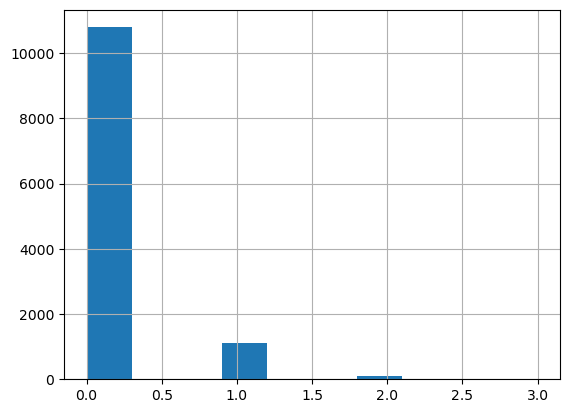

In [8]:
exploratory_df["headline_num_persons"].hist()

<Axes: >

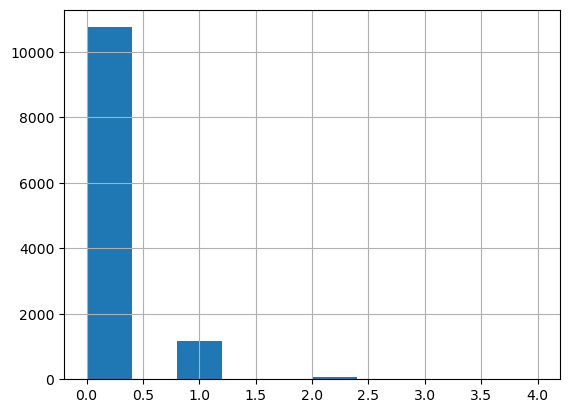

In [9]:
exploratory_df["headline_num_orgs"].hist()

<Axes: >

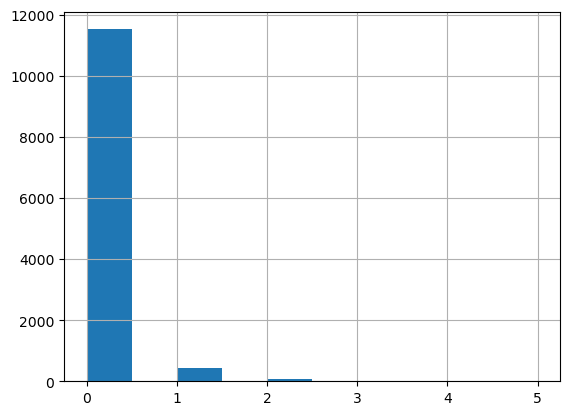

In [10]:
exploratory_df["headline_num_gpes"].hist()

In [11]:
print(exploratory_df["headline_has_person"].value_counts())
print(exploratory_df["headline_has_org"].value_counts())
print(exploratory_df["headline_has_gpe"].value_counts())

headline_has_person
False    10796
True      1214
Name: count, dtype: int64
headline_has_org
False    10749
True      1261
Name: count, dtype: int64
headline_has_gpe
False    11522
True       488
Name: count, dtype: int64


## Other features

I'll also extract some simple features that may be useful for the prediction:
- starts_with_verb
- starts_with_pronoun
- starts_with_number
- num_pronouns
- num_chars
- num_tokens
- avg_token_len
- ends_with_qmark
- ends_with_exclaim
- has_quote
- has_all_caps_word
- num_nouns
- num_verbs
- num_adjs
- num_advs
- num_pronouns

At worst they won't hurt.

In [12]:
import numpy as np

def extract_other_features(df: pd.DataFrame) -> pd.DataFrame:
    texts = df["headline"].fillna("").tolist()
    feature_rows = []

    for doc in nlp.pipe(texts, batch_size=256, n_process=4):
        tokens = [t for t in doc if not t.is_space]
        content_tokens = [t for t in tokens if not t.is_punct]
        first_token = content_tokens[0] if content_tokens else None

        # First token is a verb or an auxiliary
        starts_with_verb = (first_token is not None and first_token.pos_ in ("VERB", "AUX"))
        # First token is a pronoun
        starts_with_pronoun = first_token is not None and first_token.pos_ == "PRON"
        # First token is a number
        starts_with_number = (first_token is not None and (first_token.like_num or first_token.pos_ == "NUM"))
        # Calculate length
        text = doc.text
        num_chars = len(text)
        num_tokens = len(tokens)
        avg_token_len = float(sum(len(t.text) for t in tokens)) / num_tokens if num_tokens > 0 else 0.0

        stripped = text.rstrip()
        ends_with_qmark = stripped.endswith("?")
        ends_with_exclaim = stripped.endswith("!")
        quote_chars = ['"', "'", "“", "”", "‘", "’"]
        has_quote = any(ch in text for ch in quote_chars)

        has_all_caps_word = any(tok.is_alpha and tok.text.isupper() and len(tok.text) > 1 for tok in tokens)

        num_nouns = sum(t.pos_ in ("NOUN", "PROPN") for t in tokens)
        num_verbs = sum(t.pos_ in ("VERB", "AUX") for t in tokens)
        num_adjs = sum(t.pos_ == "ADJ" for t in tokens)
        num_advs = sum(t.pos_ == "ADV" for t in tokens)
        num_pronouns = sum(t.pos_ == "PRON" for t in tokens)
        
        feature_rows.append(
            {
                "starts_with_verb": starts_with_verb,
                "starts_with_pronoun": starts_with_pronoun,
                "starts_with_number": starts_with_number,
                "num_pronouns": num_pronouns,
                "num_chars": num_chars,
                "num_tokens": num_tokens,
                "avg_token_len": avg_token_len,
                "ends_with_qmark": ends_with_qmark,
                "ends_with_exclaim": ends_with_exclaim,
                "has_quote": has_quote,
                "has_all_caps_word": has_all_caps_word,
                "num_nouns": num_nouns,
                "num_verbs": num_verbs,
                "num_adjs": num_adjs,
                "num_advs": num_advs,
            }
        )

    features = pd.DataFrame(feature_rows, index=df.index)
    df = pd.concat([df, features], axis=1)
    return df

exploratory_df = extract_other_features(exploratory_df)

exploratory_df[[
    "headline",
    "starts_with_verb",
    "starts_with_pronoun",
    "starts_with_number",
    "num_pronouns",
    "num_chars",
    "num_tokens",
    "avg_token_len",
    "ends_with_qmark",
    "ends_with_exclaim",
    "has_quote",
    "has_all_caps_word",
    "num_nouns",
    "num_verbs",
    "num_adjs",
    "num_advs",
]].head()

,headline,starts_with_verb,starts_with_pronoun,starts_with_number,num_pronouns,num_chars,num_tokens,avg_token_len,ends_with_qmark,ends_with_exclaim,has_quote,has_all_caps_word,num_nouns,num_verbs,num_adjs,num_advs
0,What They Learned From The Scientist Was Terri...,False,True,False,5,89,18,4.166667,False,False,True,False,2,5,0,0
1,A Science Guy Helps 3 Dudes From America Under...,False,False,False,2,82,15,4.600000,False,False,True,False,5,2,0,1
2,He Sat Them Down And Told Them About An Immine...,False,True,False,5,92,19,3.894737,False,False,False,False,3,4,0,1
3,"The 3 Of Them Needed To See It In Person, And ...",False,False,False,4,95,22,3.409091,False,False,False,False,2,4,2,1
4,"They May Not Be The Most Handsome Dudes, But T...",False,True,False,3,89,20,3.700000,False,False,True,False,2,4,2,1


Apply the same to the confirmatory and holdout datasets.

In [13]:
confirmatory_df = extract_other_features(confirmatory_df)
holdout_df = extract_other_features(holdout_df)

## Sentence Structure Analysis

### Identify if the sentence has an imperative style

In [14]:
def has_imperative_style_doc(doc) -> bool:
    # Get the root of the sentence
    roots = [t for t in doc if t.dep_ == "ROOT"]
    for root in roots:
        # If the verb is in simple tense
        if root.pos_ == "VERB" and root.tag_ == "VB":
            # If no subject token has this verb as the dependency
            if not any(t.head == root and t.dep_ in ["nsubj", "nsubjpass", "csubj"] for t in doc):
                return True
    return False

def extract_imperative_style(df: pd.DataFrame) -> pd.DataFrame:
    texts = df["headline"].fillna("").tolist()

    imperative_styles = []
    for doc in nlp.pipe(texts, batch_size=256, n_process=4):
        imperative_styles.append(has_imperative_style_doc(doc))

    df["headline_imperative_verb"] = imperative_styles
    return df

exploratory_df = extract_imperative_style(exploratory_df)

In [15]:
print(exploratory_df["headline_imperative_verb"].value_counts())

headline_imperative_verb
False    10649
True      1361
Name: count, dtype: int64


Apply the same to the confirmatory and holdout datasets.

In [16]:
confirmatory_df = extract_imperative_style(confirmatory_df)
holdout_df = extract_imperative_style(holdout_df)

I tried to use SpaCy "mood" attribute which should return "Imp" if it detects an imperative sentence, but it didn't find it for any of the sentences.

### Identify if the headline has a word to incentivize curiosity

The words "why", "what", "how", "this", "these", "secrets" could be related to curiosity. I will analyze if the headline contains not just one of these words, but if it contains a word that is near to those using embeddings generated by the SpaCy model.

In [17]:
CURIOSITY_WORDS = ["why", "what", "how", "this", "these", "secrets"]
curiosity_embeddings = { word: nlp(word) for word in CURIOSITY_WORDS }

INTENSITY_WORDS = ["very", "really", "incredibly", "so", "absolutely"]
intensity_embeddings = { word: nlp(word) for word in INTENSITY_WORDS }

def extract_curiosity_and_intensity_features(df: pd.DataFrame) -> pd.DataFrame:
    texts = df["headline"].fillna("").tolist()

    has_curiosity_word = []
    curiosity_similarities = []
    has_intensity_word = []
    intensity_similarities = []

    for doc in nlp.pipe(texts, batch_size=256):
        text = doc.text

        # exact match check
        has_curiosity_word.append(any(word in text for word in CURIOSITY_WORDS))
        has_intensity_word.append(any(word in text for word in INTENSITY_WORDS))

        # semantic similarity to curiosity words
        curiosity_sims = [doc.similarity(emb_doc) for emb_doc in curiosity_embeddings.values()]
        curiosity_max_sim = max(curiosity_sims) if curiosity_sims else 0.0

        curiosity_similarities.append(curiosity_max_sim)

        intensity_sims = [doc.similarity(emb_doc) for emb_doc in intensity_embeddings.values()]
        intensity_max_sim = max(intensity_sims) if intensity_sims else 0.0
        intensity_similarities.append(intensity_max_sim)

    df["headline_has_curiosity_word"] = has_curiosity_word
    df["headline_curiosity_similarity"] = curiosity_similarities
    df["headline_has_intensity_word"] = has_intensity_word
    df["headline_intensity_similarity"] = intensity_similarities

    return df

exploratory_df = extract_curiosity_and_intensity_features(exploratory_df)

print(exploratory_df["headline_has_curiosity_word"].value_counts())
print(exploratory_df["headline_curiosity_similarity"].value_counts())
print(exploratory_df["headline_has_intensity_word"].value_counts())
print(exploratory_df["headline_intensity_similarity"].value_counts())
exploratory_df[["headline", "headline_has_curiosity_word", "headline_curiosity_similarity", "headline_has_intensity_word", "headline_intensity_similarity"]][:20]


headline_has_curiosity_word
False    11453
True       557
Name: count, dtype: int64
headline_curiosity_similarity
0.758848    9
0.860854    8
0.950995    7
0.895670    7
0.847745    7
           ..
0.886371    1
0.890923    1
0.929804    1
0.860720    1
0.858629    1
Name: count, Length: 10750, dtype: int64
headline_has_intensity_word
False    10362
True      1648
Name: count, dtype: int64
headline_intensity_similarity
0.758848    9
0.860854    8
0.950995    7
0.895670    7
0.847745    7
           ..
0.886371    1
0.890923    1
0.929804    1
0.860720    1
0.858629    1
Name: count, Length: 10750, dtype: int64


,headline,headline_has_curiosity_word,headline_curiosity_similarity,headline_has_intensity_word,headline_intensity_similarity
0,What They Learned From The Scientist Was Terri...,False,0.942614,False,0.942614
1,A Science Guy Helps 3 Dudes From America Under...,False,0.892486,False,0.892486
2,He Sat Them Down And Told Them About An Immine...,False,0.799320,False,0.799320
3,"The 3 Of Them Needed To See It In Person, And ...",False,0.895029,True,0.895029
4,"They May Not Be The Most Handsome Dudes, But T...",False,0.949511,True,0.949511
5,"The Selfies Were Already Bad Enough, But Then ...",False,0.944724,True,0.944724
6,Warning: Beware Of Her Selfies And Stereotypes...,False,0.900845,True,0.900845
7,"Sigh... I Wanted To Like This Woman, But The S...",False,0.949785,True,0.949785
8,A Couple That Loves To Travel Together Came Up...,False,0.836295,False,0.836295
9,My Mom Forced Me To Study When I Was A Kid. Th...,False,0.907956,False,0.907956


Apply the same to the confirmatory and holdout datasets.

In [18]:
confirmatory_df = extract_curiosity_and_intensity_features(confirmatory_df)
holdout_df = extract_curiosity_and_intensity_features(holdout_df)

/var/folders/fw/s4mlw4vx2hx944qtl0q1vcfm0000gn/T/ipykernel_18534/3691462791.py:23: UserWarning: [W008] Evaluating Doc.similarity based on empty vectors.
  curiosity_sims = [doc.similarity(emb_doc) for emb_doc in curiosity_embeddings.values()]
/var/folders/fw/s4mlw4vx2hx944qtl0q1vcfm0000gn/T/ipykernel_18534/3691462791.py:28: UserWarning: [W008] Evaluating Doc.similarity based on empty vectors.
  intensity_sims = [doc.similarity(emb_doc) for emb_doc in intensity_embeddings.values()]


## Sentiment Analysis

To do sentiment analysis I'll use the VADER sentiment analysis tool from the NLTK library.

I analyzed the use of VADER vs LWIC method. The second one is motly based on a sentiment dictionary, while VADER looks at punctuation and word context.

VADER is supposed to work better with social media and short text in general. LWIC is expected to be more accurate for longer text.

The material "Negativity drives online news consumption (2023)" uses LWIC to analyze the sentiment of the headlines.

The paper "Headline sentiment and topic effect on online user engagement (2021)" uses TextBlob for sentiment analysis. Based on the research of how this method works, it may also be more accurate for longer texts.

In [19]:
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

nltk.download('vader_lexicon')

sentiment_analyzer = SentimentIntensityAnalyzer()

# Apply VADER to each headline
sentiment_df = exploratory_df['headline'].apply(sentiment_analyzer.polarity_scores).apply(pd.Series)
exploratory_df = pd.concat([exploratory_df, sentiment_df], axis=1)

exploratory_df[["headline", "neg", "neu", "pos", "compound"]].describe()

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/damiancalabresi/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


,neg,neu,pos,compound
count,12010.000000,12010.000000,12010.000000,12010.000000
mean,0.095878,0.782866,0.121254,0.054009
std,0.121396,0.159466,0.133766,0.439771
min,0.000000,0.182000,0.000000,-0.948500
25%,0.000000,0.673000,0.000000,-0.275500
50%,0.000000,0.790000,0.107000,0.000000
75%,0.176000,0.896000,0.207750,0.421500
max,0.718000,1.000000,0.818000,0.951700


The mean for compound is 0.05, which means that the sentiment is mostly neutral. The variance is high but not too much. Sentiment can still be considered.

In [20]:
exploratory_df[["headline", "neg", "neu", "pos", "compound"]].head()

,headline,neg,neu,pos,compound
0,What They Learned From The Scientist Was Terri...,0.144,0.856,0.000,-0.3291
1,A Science Guy Helps 3 Dudes From America Under...,0.000,0.809,0.191,0.3818
2,He Sat Them Down And Told Them About An Immine...,0.187,0.813,0.000,-0.5994
3,"The 3 Of Them Needed To See It In Person, And ...",0.124,0.720,0.156,0.2023
4,"They May Not Be The Most Handsome Dudes, But T...",0.000,0.655,0.345,0.7812


Apply the same to the confirmatory and holdout datasets.

In [21]:
sentiment_df = confirmatory_df['headline'].apply(sentiment_analyzer.polarity_scores).apply(pd.Series)
confirmatory_df = pd.concat([confirmatory_df, sentiment_df], axis=1)

holdout_sentiment_df = holdout_df['headline'].fillna("").astype(str).apply(sentiment_analyzer.polarity_scores).apply(pd.Series)
holdout_df = pd.concat([holdout_df, holdout_sentiment_df], axis=1)


## Dataset related features



In [22]:
exploratory_df["created_at"] = pd.to_datetime(exploratory_df["created_at"], format="mixed")
confirmatory_df["created_at"] = pd.to_datetime(confirmatory_df["created_at"], format="mixed")
holdout_df["created_at"] = pd.to_datetime(holdout_df["created_at"], format="mixed")

# Day of the week
exploratory_df["created_at_dayofweek"] = exploratory_df["created_at"].dt.dayofweek
confirmatory_df["created_at_dayofweek"] = confirmatory_df["created_at"].dt.dayofweek
holdout_df["created_at_dayofweek"] = holdout_df["created_at"].dt.dayofweek

# Hour of the day
exploratory_df["created_at_hourofday"] = exploratory_df["created_at"].dt.hour
confirmatory_df["created_at_hourofday"] = confirmatory_df["created_at"].dt.hour
holdout_df["created_at_hourofday"] = holdout_df["created_at"].dt.hour


Each test has a number of packages, could be 2, 3, 4, etc. A given package is competing with the other packages in the test. This will be important to calculate the probability of winning the competition in a random scenario.

I'll add to each package the number of other packages in the test.




In [23]:
exploratory_df["test_group_size"] = exploratory_df.groupby("clickability_test_id")["clickability_test_id"].transform("size")
confirmatory_df["test_group_size"] = confirmatory_df.groupby("clickability_test_id")["clickability_test_id"].transform("size")
holdout_df["test_group_size"] = holdout_df.groupby("clickability_test_id")["clickability_test_id"].transform("size")

In [24]:
exploratory_df[["clickability_test_id", "test_group_size"]][:20]

,clickability_test_id,test_group_size
0,546e009a9ad54ec65b00004b,6
1,546e009a9ad54ec65b00004b,6
2,546e009a9ad54ec65b00004b,6
3,546e009a9ad54ec65b00004b,6
4,546e009a9ad54ec65b00004b,6
5,546cb9c954524053ac000013,4
6,546cb9c954524053ac000013,4
7,546cb9c954524053ac000013,4
8,546e454a9ad54e2af0000070,6
9,54d1967c63666200191c0000,6


## Readability Score

The paper "Linguistic effects on news headline success: Evidence from thousands of online field experiments (2023)" uses the Flesch Reading Ease score to measure the readability of the headlines.

The problem is that Flesch Reading Ease score is based on the number of syllables in the words. Headlines are very short, so word based metrics may not be very accurate.

I'll also calculate the readability using the Coleman-Liau index which is based on the number of characters per word and may be better for short texts.

In [25]:
from textstat import textstat


def readability_scores(text: str) -> pd.Series:
    return pd.Series(
        {
           "read_flesch": textstat.flesch_reading_ease(text),
            "read_coleman": textstat.coleman_liau_index(text),
        }
    )

exploratory_df[["read_flesch","read_coleman"]] = exploratory_df["headline"].apply(readability_scores)
confirmatory_df[["read_flesch","read_coleman"]] = confirmatory_df["headline"].apply(readability_scores)
holdout_df[["read_flesch","read_coleman"]] = holdout_df["headline"].fillna("").astype(str).apply(readability_scores)

exploratory_df[["headline", "read_flesch", "read_coleman"]].describe()


,read_flesch,read_coleman
count,12010.000000,12010.000000
mean,74.142872,6.962282
std,19.011762,3.632964
min,-61.600000,-6.766667
25%,63.695000,4.450000
50%,76.501538,6.647059
75%,87.677500,9.137500
max,119.190000,30.450000


In [26]:
exploratory_df[["headline", "read_flesch", "read_coleman"]][:20]

,headline,read_flesch,read_coleman
0,What They Learned From The Scientist Was Terri...,80.782500,8.093333
1,A Science Guy Helps 3 Dudes From America Under...,59.682143,10.257143
2,He Sat Them Down And Told Them About An Immine...,80.465000,6.077778
3,"The 3 Of Them Needed To See It In Person, And ...",80.777143,3.228571
4,"They May Not Be The Most Handsome Dudes, But T...",92.965000,5.875000
5,"The Selfies Were Already Bad Enough, But Then ...",73.795735,8.352941
6,Warning: Beware Of Her Selfies And Stereotypes...,50.560577,12.215385
7,"Sigh... I Wanted To Like This Woman, But The S...",80.200000,5.400000
8,A Couple That Loves To Travel Together Came Up...,63.486154,5.569231
9,My Mom Forced Me To Study When I Was A Kid. Th...,103.379091,1.281818


## Generality using TF-IDF

The paper "Linguistic effects on news headline success: Evidence from thousands of online field experiments (2023)" also calculates the Generality vs Specificity of the headlines.

To do this, I'll use the Scikit-learn TF-IDF vectorizer and calculate the TF-IDF score for each headline. A higher TF-IDF should mean the headline is more specific.


In [27]:
from sklearn.feature_extraction.text import TfidfVectorizer

# To have a bigger corpus, I'll use the entire dataset
exploratory_texts = exploratory_df["headline"].fillna("").tolist()
confirmatory_texts = confirmatory_df["headline"].fillna("").tolist()
holdout_texts = holdout_df["headline"].fillna("").tolist()
all_texts = exploratory_texts + confirmatory_texts + holdout_texts

# Ensure this will only use unigrams
vectorizer = TfidfVectorizer(lowercase=True, stop_words="english", ngram_range=(1, 1))
# This will return a sparse matrix with the TF-IDF scores for each headline and each word
X_all = vectorizer.fit_transform(all_texts)

# Now I'll sum the TF-IDF scores for each headline
# Then calculate the columns different than 0, which represents the number of words in the headline
# And finally I'll calculate the average
headlines_tfidf_sum = X_all.sum(axis=1).A1
headline_number_terms = (X_all != 0).sum(axis=1).A1
# Calculate the average
# When the number of terms is 0 (There are some empty headlines in the holdout set), the score is 0
headlines_average_tfidf = np.divide(headlines_tfidf_sum, headline_number_terms, out=np.zeros_like(headlines_tfidf_sum), where=headline_number_terms != 0)

exploratory_df["specificity_tfidf"] = headlines_average_tfidf[:len(exploratory_df)]
confirmatory_df["specificity_tfidf"] = headlines_average_tfidf[len(exploratory_df):len(exploratory_df) + len(confirmatory_df)]
holdout_df["specificity_tfidf"] = headlines_average_tfidf[len(exploratory_df) + len(confirmatory_df):]


In [28]:
exploratory_df[["headline", "specificity_tfidf"]][:40]

,headline,specificity_tfidf
0,What They Learned From The Scientist Was Terri...,0.444616
1,A Science Guy Helps 3 Dudes From America Under...,0.370851
2,He Sat Them Down And Told Them About An Immine...,0.398801
3,"The 3 Of Them Needed To See It In Person, And ...",0.445514
4,"They May Not Be The Most Handsome Dudes, But T...",0.497006
5,"The Selfies Were Already Bad Enough, But Then ...",0.489082
6,Warning: Beware Of Her Selfies And Stereotypes...,0.368344
7,"Sigh... I Wanted To Like This Woman, But The S...",0.428207
8,A Couple That Loves To Travel Together Came Up...,0.405103
9,My Mom Forced Me To Study When I Was A Kid. Th...,0.325372


## Export results

In [29]:
exploratory_df.to_csv("dataset/processed/exploratory-packages-feature-engineering.csv", index=False)
confirmatory_df.to_csv("dataset/processed/confirmatory-packages-feature-engineering.csv", index=False)
holdout_df.to_csv("dataset/processed/holdout-packages-feature-engineering.csv", index=False)